# Fase 1: Exploración y Limpieza

## 1. Exploración Inicial + 2. Limpieza de Datos:

Voy a realizar primero la exploración y limpieza de datos, y posteriormente uniré los dos DF, por lo que haré los 2 puntos de manera enlazada.

Realiza una exploración inicial de los datos para identificar posibles problemas, como valores nulos, atípicos o datos faltantes en las columnas relevantes.

In [1]:
# Importamos las librerías que nos van a hacer falta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_flight = pd.read_csv('files/Customer Flight Activity.csv')
df_loyalty = pd.read_csv('files/Customer Loyalty History.csv')

In [3]:
# Vamos a mostrar las primeras 5 líneas de cada DF para hacernos una idea de cómo son (sus columnas, tipos de datos, etc)

df_flight.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0
2,100140,2017,1,6,0,6,1200,120.0,0,0
3,100214,2017,1,0,0,0,0,0.0,0,0
4,100272,2017,1,0,0,0,0,0.0,0,0


In [4]:
df_loyalty.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


In [5]:
# Con esta info podemos concluir que todas las columnas de este DF son numéricas y que, en principio, no hay nulos.

df_flight.info()

<class 'pandas.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB


In [ ]:
# En esta columna en cambio hay datos numéricos y también categóricos y algunas columnas sí que tienen nulos.

df_loyalty.info()

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  str    
 2   Province            16737 non-null  str    
 3   City                16737 non-null  str    
 4   Postal Code         16737 non-null  str    
 5   Gender              16737 non-null  str    
 6   Education           16737 non-null  str    
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  str    
 9   Loyalty Card        16737 non-null  str    
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  str    
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: float64(4), 

In [ ]:
# Vamos a comprobar si hay duplicados (en el caso de loyalty cada cliente debde ser único, y vemos que no hay duplicados).

df_loyalty.duplicated(subset="Loyalty Number").sum()

np.int64(0)

In [11]:
# En flight vemos que se repiten cada año de cada mes, así que debemos indicar esos filtros en la comprobación.

df_flight.duplicated(subset=["Loyalty Number", "Year", "Month"]).sum()

np.int64(3936)

In [ ]:
# Podemos ver que incluso aplicando esos filtros existen duplicados que debemos eliminar. 


df_flight[df_flight.duplicated(subset=["Loyalty Number", "Year", "Month"], keep=False)]

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
41,101902,2017,1,0,0,0,0,0.0,0,0
42,101902,2017,1,0,0,0,0,0.0,0,0
114,106001,2017,1,9,4,13,1365,136.0,0,0
115,106001,2017,1,5,0,5,910,91.0,0,0
226,112142,2017,1,0,0,0,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...
405437,989528,2018,12,0,0,0,0,0.0,0,0
405451,990512,2018,12,15,5,20,2940,294.0,0,0
405452,990512,2018,12,5,2,7,3906,390.0,0,0
405486,992168,2018,12,15,0,15,3120,312.0,0,0


In [13]:
# Dado que la regla parece ser que el primero que aparece tiene más datos que el segundo, vamos a quedarnos con la primera fila de cada uno.

df_flight = df_flight.drop_duplicates(subset=["Loyalty Number", "Year", "Month"], keep="first")

In [ ]:
# Vemos que efectivamente el número de entradas ha disminuído al eliminar los duplicados.

df_flight.info()

<class 'pandas.DataFrame'>
Index: 401688 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               401688 non-null  int64  
 1   Year                         401688 non-null  int64  
 2   Month                        401688 non-null  int64  
 3   Flights Booked               401688 non-null  int64  
 4   Flights with Companions      401688 non-null  int64  
 5   Total Flights                401688 non-null  int64  
 6   Distance                     401688 non-null  int64  
 7   Points Accumulated           401688 non-null  float64
 8   Points Redeemed              401688 non-null  int64  
 9   Dollar Cost Points Redeemed  401688 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 33.7 MB


In [ ]:
# Ahora vamos a comprobar si hay nulos

df_flight.isnull().sum()

Loyalty Number                 0
Year                           0
Month                          0
Flights Booked                 0
Flights with Companions        0
Total Flights                  0
Distance                       0
Points Accumulated             0
Points Redeemed                0
Dollar Cost Points Redeemed    0
dtype: int64

In [ ]:
# Vemos que en loyalty sí que hay nulos.

df_loyalty.isnull().sum()

Loyalty Number            0
Country                   0
Province                  0
City                      0
Postal Code               0
Gender                    0
Education                 0
Salary                 4238
Marital Status            0
Loyalty Card              0
CLV                       0
Enrollment Type           0
Enrollment Year           0
Enrollment Month          0
Cancellation Year     14670
Cancellation Month    14670
dtype: int64

In [ ]:
# Los nulos de Cancellation Year y Cancellation Month no son un problema porque significan que el cliente sigue teniendo la membresía activa, pero crearemos una columna que nos indique el estado de la membresía.
# Los nulos en Salary sí que suponen un problema, vamos a revisarlo bien para poder tomar una decisión.

df_loyalty["Salary"].isnull().sum() / len(df_loyalty) * 100

np.float64(25.321144769074504)

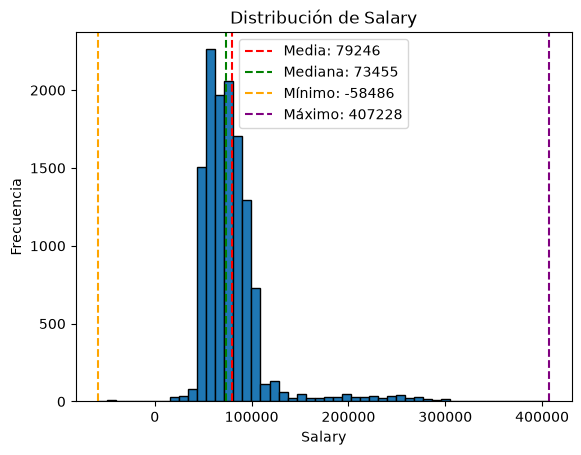

In [ ]:
fig, ax = plt.subplots()

ax.hist(df_loyalty["Salary"], bins=50, edgecolor="black")

ax.axvline(df_loyalty["Salary"].mean(), color="red", linestyle="--", label=f'Media: {df_loyalty["Salary"].mean():.0f}')
ax.axvline(df_loyalty["Salary"].median(), color="green", linestyle="--", label=f'Mediana: {df_loyalty["Salary"].median():.0f}')
ax.axvline(df_loyalty["Salary"].min(), color="orange", linestyle="--", label=f'Mínimo: {df_loyalty["Salary"].min():.0f}')
ax.axvline(df_loyalty["Salary"].max(), color="purple", linestyle="--", label=f'Máximo: {df_loyalty["Salary"].max():.0f}')

ax.set_title("Distribución de Salary")
ax.set_xlabel("Salary")
ax.set_ylabel("Frecuencia")
ax.legend()

plt.show()

# Vemos que hay salarios negativos, estos los vamos a tratar como nulos ya que nadie puede cobrar negativo.
# Vemos también que los datos están sesgados a la derecha, hay valores extremos muy por encima de los valores centrales. Esto hace que la media de salarios esté inflada.
# Dado que el porcentaje de nulos es bajo y en distribuciones asimétricas la mediana es más representativa del valor central, imputaremos los nulos con la mediana.

In [22]:
# Primero convertirmos los datos negativos en nulos, para después trtar todos los nulos juntos

df_loyalty.loc[df_loyalty["Salary"] < 0, "Salary"] = np.nan

In [24]:
# Ahora vamos a imputar los nulos con la mediana

df_loyalty["Salary"] = df_loyalty["Salary"].fillna(df_loyalty["Salary"].median())

In [25]:
# Vamos a verificar que ya no quedan nulos

df_loyalty["Salary"].isnull().sum()

np.int64(0)

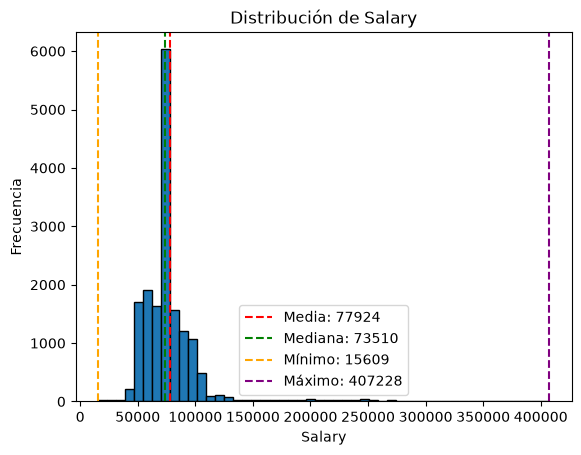

In [ ]:
# Ahora vamos a ver el resultado

fig, ax = plt.subplots()

ax.hist(df_loyalty["Salary"], bins=50, edgecolor="black")

ax.axvline(df_loyalty["Salary"].mean(), color="red", linestyle="--", label=f'Media: {df_loyalty["Salary"].mean():.0f}')
ax.axvline(df_loyalty["Salary"].median(), color="green", linestyle="--", label=f'Mediana: {df_loyalty["Salary"].median():.0f}')
ax.axvline(df_loyalty["Salary"].min(), color="orange", linestyle="--", label=f'Mínimo: {df_loyalty["Salary"].min():.0f}')
ax.axvline(df_loyalty["Salary"].max(), color="purple", linestyle="--", label=f'Máximo: {df_loyalty["Salary"].max():.0f}')

ax.set_title("Distribución de Salary")
ax.set_xlabel("Salary")
ax.set_ylabel("Frecuencia")
ax.legend()

plt.show()

# Vemos que ahora el mínimo ya es un valor positivo. Soy consciente de que imputar con la mediana distorsiona la distribución creando un pico, pero para el análisis posterior es una solución aceptable y simple.

In [ ]:
# Nos falta tratar los nulos de Cancellation Year y Cancellation Month, que hemos dicho que crearemos una columna que nos indique el esatdo en base a estas columnas.
# Lo hago así porque aquí el nulo es un dato en sí, por lo que no tiene sentido eliminarlo ni imputarlo, para trabajar con una columna sin nulos, creamos otra que interpreta este dato.

df_loyalty["Membership Status"] = df_loyalty["Cancellation Year"].isnull().map({True: "Activa", False: "Cancelada"})

In [31]:
df_loyalty.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Membership Status
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,Activa
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,73510.0,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN,Activa
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,73510.0,Single,Star,3839.75,Standard,2014,7,2018.0,1.0,Cancelada
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,73510.0,Single,Star,3839.75,Standard,2013,2,NaN,NaN,Activa
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN,Activa


In [32]:
df_loyalty.info()

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  str    
 2   Province            16737 non-null  str    
 3   City                16737 non-null  str    
 4   Postal Code         16737 non-null  str    
 5   Gender              16737 non-null  str    
 6   Education           16737 non-null  str    
 7   Salary              16737 non-null  float64
 8   Marital Status      16737 non-null  str    
 9   Loyalty Card        16737 non-null  str    
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  str    
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
 16  Membership Stat